
Dataset Shape: (150, 5)
Number of rows: 150
Number of columns: 5

Column Names:
  1. sepal_length
  2. sepal_width
  3. petal_length
  4. petal_width
  5. species

First 5 rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-n

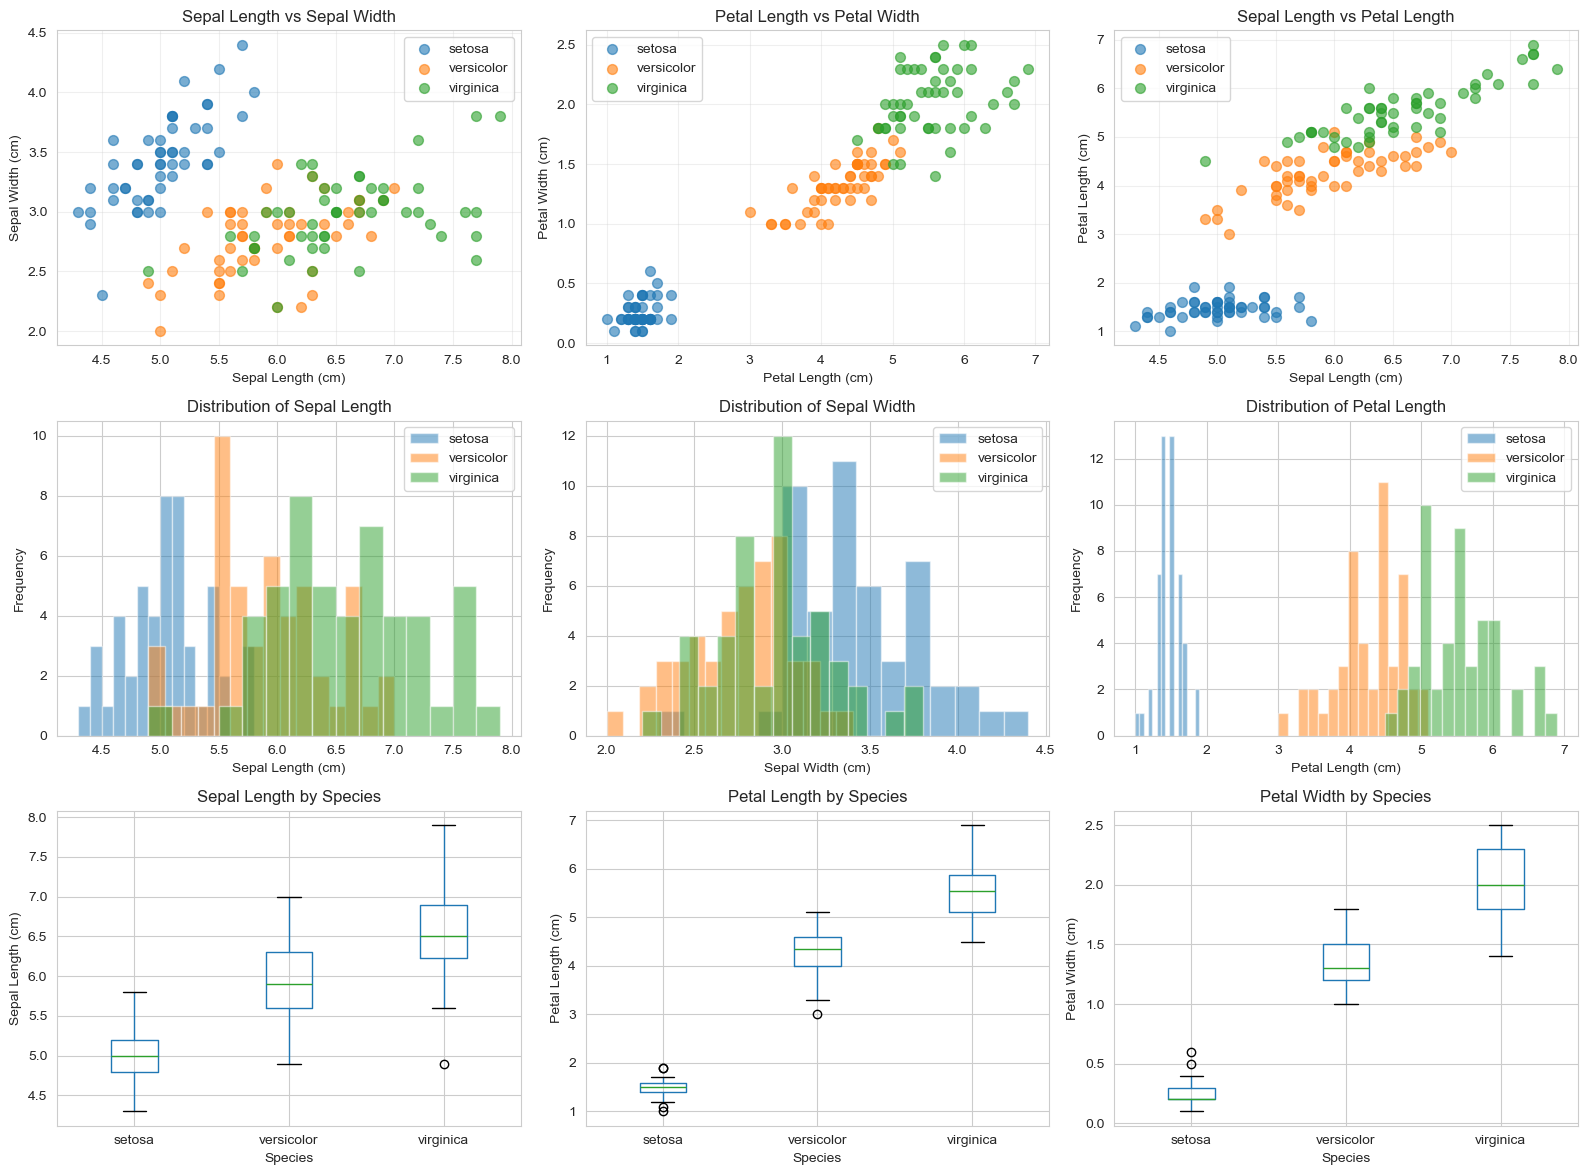


Creating pairplot...
✓ Pairplot saved as 'iris_pairplot.png'


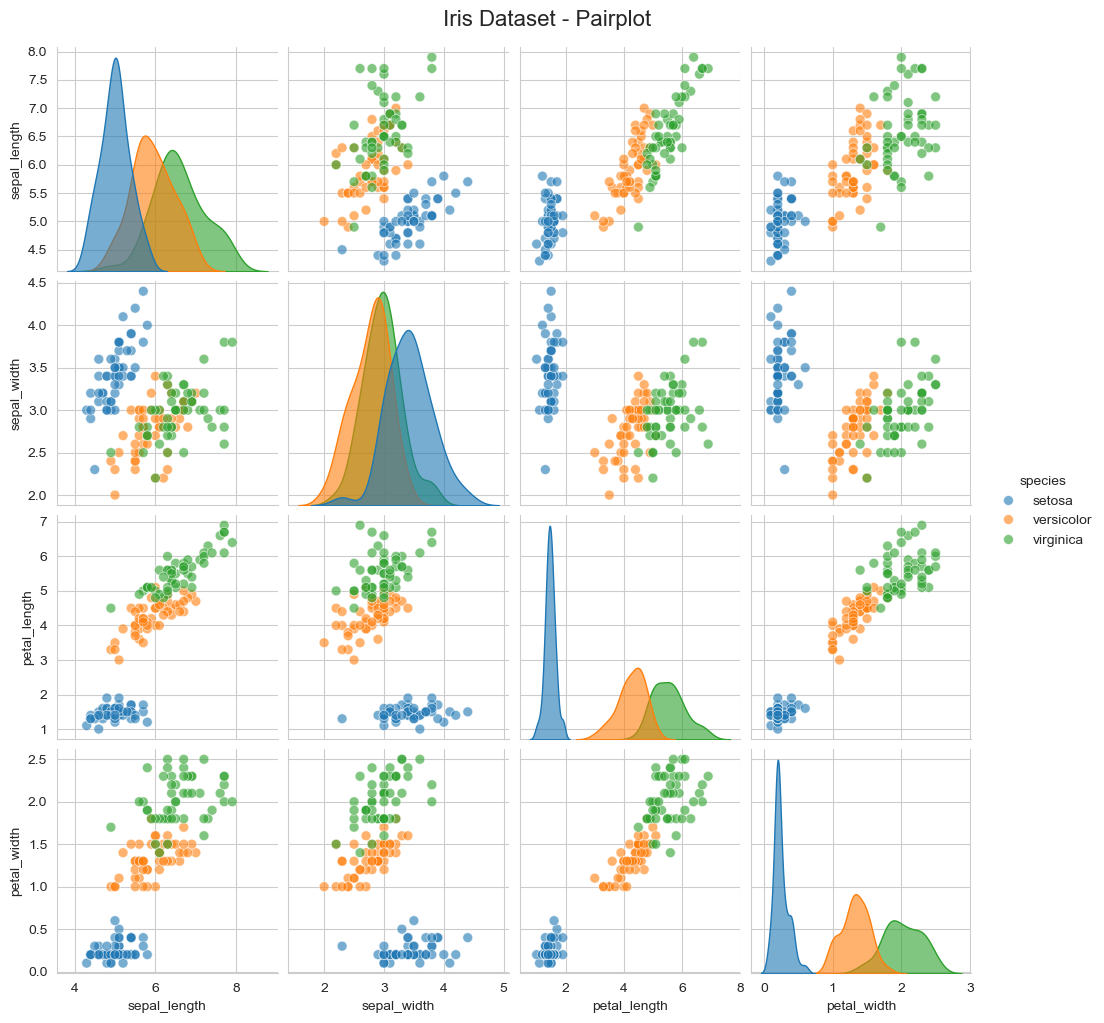


Creating correlation heatmap...
✓ Correlation heatmap saved as 'iris_correlation.png'


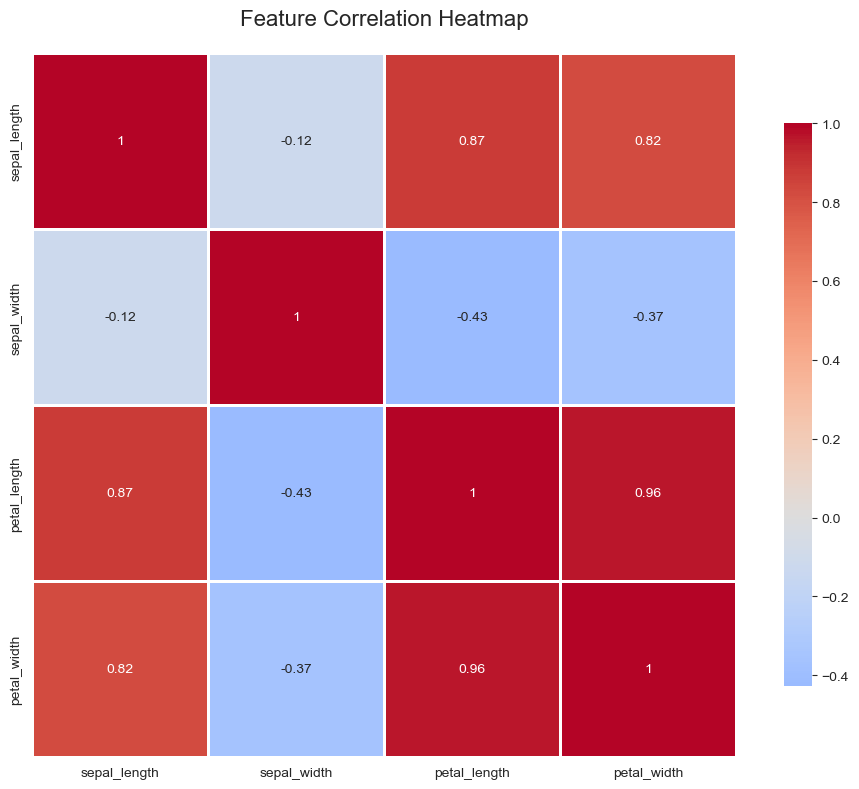


1. Dataset Overview:
   - Total samples: 150
   - Features: 4 numerical (sepal/petal measurements)
   - Target: 3 species (setosa, versicolor, virginica)
   - Balanced dataset: 50 samples per species

2. Feature Correlations:
   - Petal length & width: 0.963 (strong positive)
   - Sepal length & petal length: 0.872 (strong positive)

3. Species Separability:
   - Setosa: Clearly separable (smaller petals)
   - Versicolor & Virginica: Some overlap in feature space
   - Petal measurements are better discriminators than sepal measurements

4. Outliers:
   - Few outliers detected in box plots
   - Most outliers in sepal width measurements


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


# Load the Iris dataset from seaborn
iris = sns.load_dataset('iris')


# Print shape
print(f"\nDataset Shape: {iris.shape}")
print(f"Number of rows: {iris.shape[0]}")
print(f"Number of columns: {iris.shape[1]}")

# Print column names
print(f"\nColumn Names:")
for i, col in enumerate(iris.columns, 1):
    print(f"  {i}. {col}")

# Display first few rows
print(f"\nFirst 5 rows of the dataset:")
print(iris.head())


print("\nData types and missing values:")
iris.info()


print("\nSummary statistics for numerical features:")
print(iris.describe())

print("\nSpecies distribution:")
print(iris['species'].value_counts())



# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))


# 1. Scatter plot: Sepal Length vs Sepal Width
plt.subplot(3, 3, 1)
for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.scatter(subset['sepal_length'], subset['sepal_width'], 
                label=species, alpha=0.6, s=50)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Scatter plot: Petal Length vs Petal Width
plt.subplot(3, 3, 2)
for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.scatter(subset['petal_length'], subset['petal_width'], 
                label=species, alpha=0.6, s=50)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Petal Width')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Pairplot alternative 
plt.subplot(3, 3, 3)
for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.scatter(subset['sepal_length'], subset['petal_length'], 
                label=species, alpha=0.6, s=50)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Sepal Length vs Petal Length')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(3, 3, 4)
for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.hist(subset['sepal_length'], alpha=0.5, label=species, bins=15)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Sepal Length')
plt.legend()

# 5. Histogram: Sepal Width
plt.subplot(3, 3, 5)
for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.hist(subset['sepal_width'], alpha=0.5, label=species, bins=15)
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Sepal Width')
plt.legend()

# 6. Histogram: Petal Length
plt.subplot(3, 3, 6)
for species in iris['species'].unique():
    subset = iris[iris['species'] == species]
    plt.hist(subset['petal_length'], alpha=0.5, label=species, bins=15)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Petal Length')
plt.legend()

# ---- BOX PLOTS ----
# 7. Box plot: Sepal Length by Species
plt.subplot(3, 3, 7)
iris.boxplot(column='sepal_length', by='species', ax=plt.gca())
plt.title('Sepal Length by Species')
plt.suptitle('')  # Remove default title
plt.xlabel('Species')
plt.ylabel('Sepal Length (cm)')

# 8. Box plot: Petal Length by Species
plt.subplot(3, 3, 8)
iris.boxplot(column='petal_length', by='species', ax=plt.gca())
plt.title('Petal Length by Species')
plt.suptitle('')
plt.xlabel('Species')
plt.ylabel('Petal Length (cm)')

# 9. Box plot: Petal Width by Species
plt.subplot(3, 3, 9)
iris.boxplot(column='petal_width', by='species', ax=plt.gca())
plt.title('Petal Width by Species')
plt.suptitle('')
plt.xlabel('Species')
plt.ylabel('Petal Width (cm)')

plt.tight_layout()
plt.savefig('iris_exploration.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'iris_exploration.png'")
plt.show()

# Create a beautiful pairplot
print("\nCreating pairplot...")
pairplot = sns.pairplot(iris, hue='species', diag_kind='kde', 
                         plot_kws={'alpha': 0.6, 's': 50},
                         diag_kws={'alpha': 0.6})
pairplot.fig.suptitle('Iris Dataset - Pairplot', y=1.02, fontsize=16)
plt.savefig('iris_pairplot.png', dpi=300, bbox_inches='tight')
print("✓ Pairplot saved as 'iris_pairplot.png'")
plt.show()

# Create a correlation heatmap
print("\nCreating correlation heatmap...")
plt.figure(figsize=(10, 8))
# Calculate correlation matrix for numerical features only
corr_matrix = iris.drop('species', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('iris_correlation.png', dpi=300, bbox_inches='tight')
print("✓ Correlation heatmap saved as 'iris_correlation.png'")
plt.show()


print("\n1. Dataset Overview:")
print(f"   - Total samples: {len(iris)}")
print(f"   - Features: 4 numerical (sepal/petal measurements)")
print(f"   - Target: 3 species (setosa, versicolor, virginica)")
print(f"   - Balanced dataset: {iris['species'].value_counts().values[0]} samples per species")

print("\n2. Feature Correlations:")
print(f"   - Petal length & width: {corr_matrix.loc['petal_length', 'petal_width']:.3f} (strong positive)")
print(f"   - Sepal length & petal length: {corr_matrix.loc['sepal_length', 'petal_length']:.3f} (strong positive)")

print("\n3. Species Separability:")
print("   - Setosa: Clearly separable (smaller petals)")
print("   - Versicolor & Virginica: Some overlap in feature space")
print("   - Petal measurements are better discriminators than sepal measurements")

print("\n4. Outliers:")
print("   - Few outliers detected in box plots")
print("   - Most outliers in sepal width measurements")

